In [1]:
import os

from pathlib import Path

import h5py
import matplotlib.pyplot as plt

import numpy as np



In [11]:
FILE_PATH = Path("../data/BIIAX_196(245)_02/BIIAX_196(245)_02_2026-04-17_103446/tomo-A/BIIAX_196(245)_02_tomo-A_recon_crop_ztrim150.h5")

In [12]:
with h5py.File(FILE_PATH, "r") as f:
    ds = f["volume"]
    Z, Y, X = ds.shape

    raw = ds[:,:100,:].astype(np.float32)

print(f"Slab : {raw.shape}")
print(f"Range: [{raw.min():.0f}, {raw.max():.0f}]  mean={raw.mean():.0f}")

Slab : (1706, 100, 1383)
Range: [2561, 65535]  mean=16011


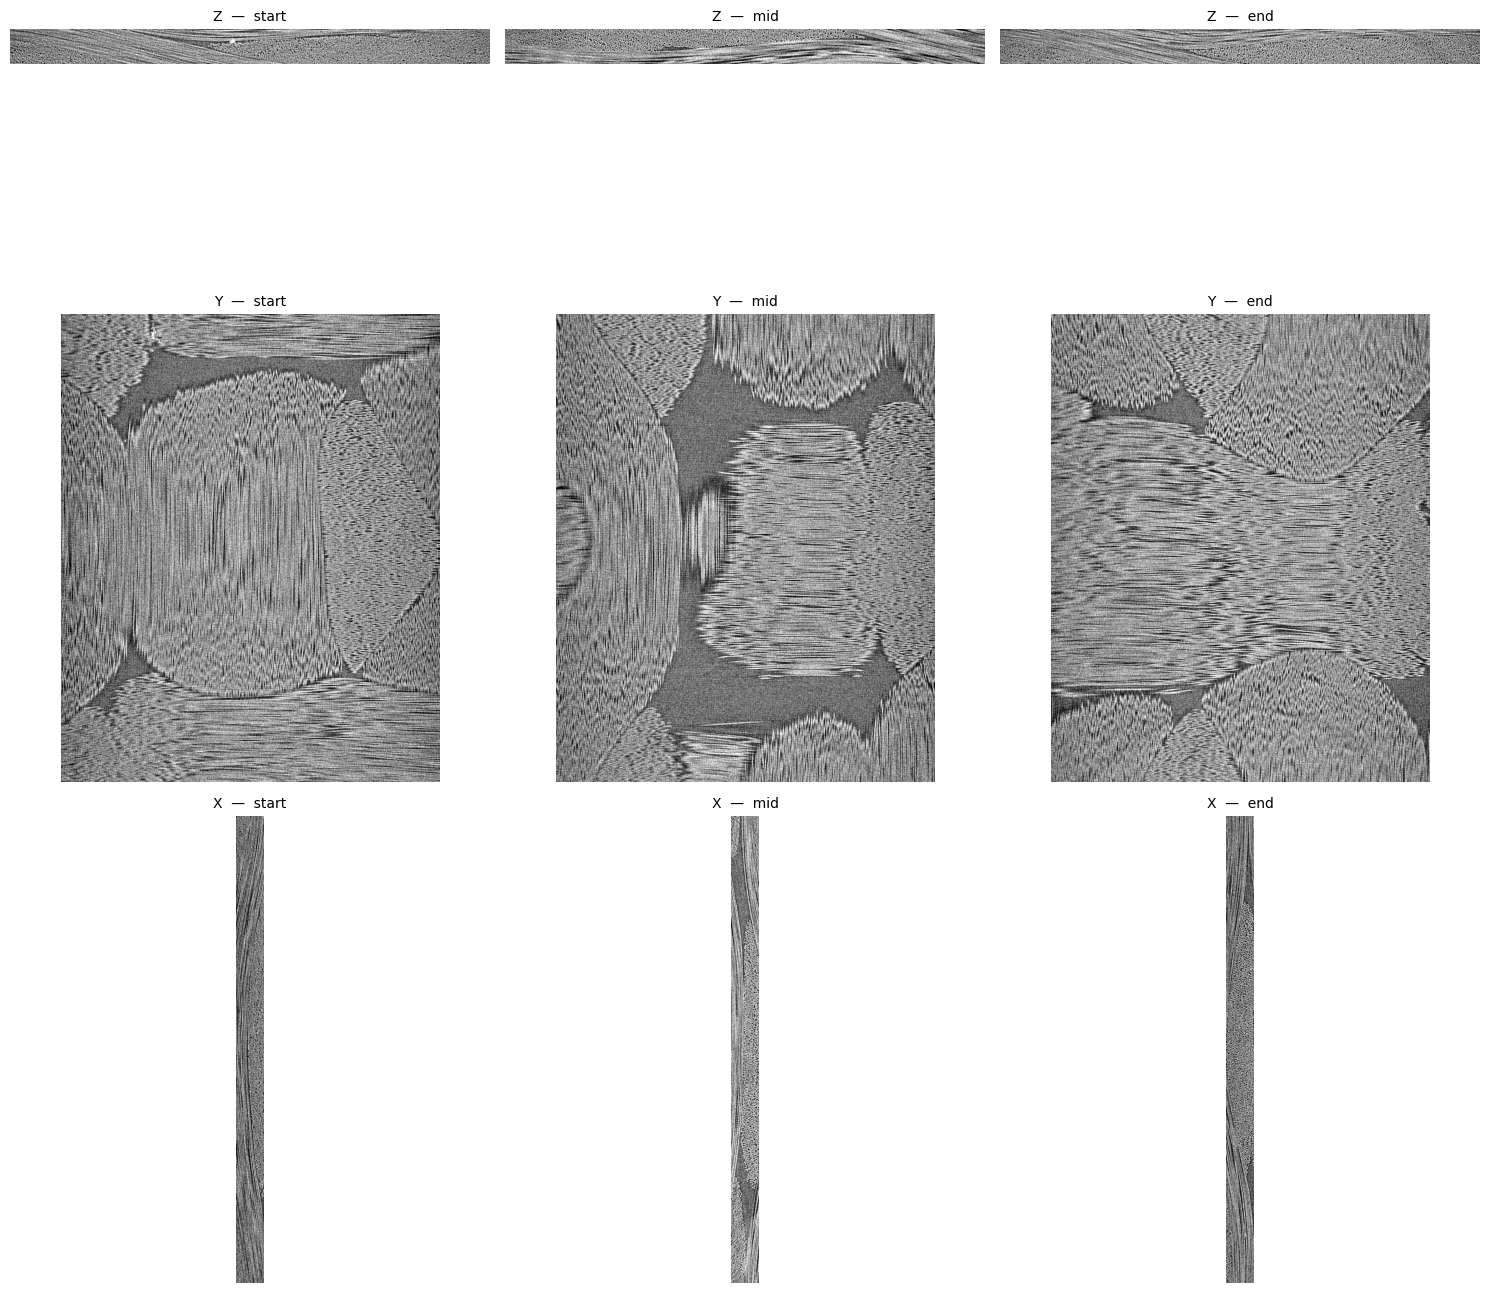

In [13]:
vlo, vhi = np.percentile(raw, [1, 99])

directions = [
    ("Z", raw[0],        raw[raw.shape[0] // 2],  raw[-1]),
    ("Y", raw[:, 0],     raw[:, raw.shape[1] // 2], raw[:, -1]),
    ("X", raw[:, :, 0],  raw[:, :, raw.shape[2] // 2], raw[:, :, -1]),
]

fig, axs = plt.subplots(3, 3, figsize=(15, 15))

for row, (axis, start, mid, end) in enumerate(directions):
    for col, (img, label) in enumerate([(start, "start"), (mid, "mid"), (end, "end")]):
        axs[row, col].imshow(img, cmap="gray", vmin=vlo, vmax=vhi)
        axs[row, col].set_title(f"{axis}  —  {label}", fontsize=10)
        axs[row, col].axis("off")

plt.tight_layout()
plt.show()

## Background removal — full 3-D Gaussian, pure PyTorch MPS

A 3-D Gaussian is **separable**: `G_3D(x,y,z) = G_X(x)·G_Y(y)·G_Z(z)`.  
This lets us replace one huge 3-D kernel with three sequential 1-D `F.conv3d` passes:

| Pass | Kernel shape | Iterates over | GPU batch size |
|------|-------------|--------------|----------------|
| X | `(1,1,1,1,K)` | Z-slabs | `batch_z` slices |
| Y | `(1,1,1,K,1)` | Z-slabs | `batch_z` slices |
| Z | `(1,1,K,1,1)` | Y-strips | all Z, `strip_y` rows |

Reflect padding on all axes. No scipy. Memory overhead: one `bg` buffer + small working copies.

Install PyTorch if needed:
```
pip install torch torchvision torchaudio
```

In [5]:
import torch
import torch.nn.functional as F


device = (
    torch.device("mps")  if torch.backends.mps.is_available()  else
    torch.device("cuda") if torch.cuda.is_available()          else
    torch.device("cpu")
)

Z, H, W = raw.shape
print(f"Device  : {device}")
print(f"Volume  : {raw.shape}  {raw.dtype}  ({raw.nbytes / 1e9:.1f} GB)")

Device  : mps
Volume  : (2006, 100, 1383)  float32  (1.1 GB)


raw   : range=[3997, 33015]  mean=15758
corrected: range=[-11364, 16043]  mean=3


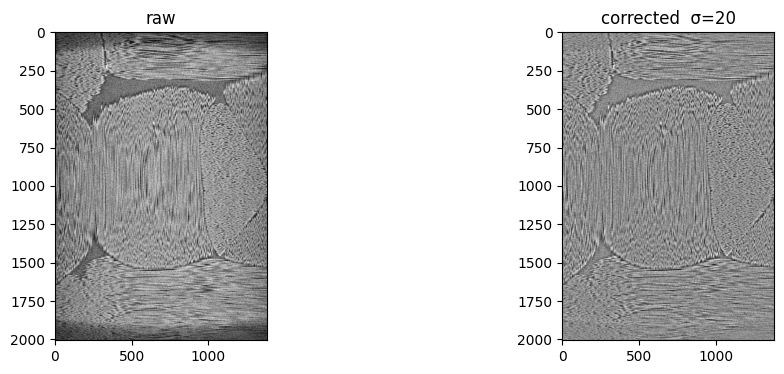

In [10]:
sigma = 20.0
r = int(4 * sigma + 0.5)
k = torch.arange(-r, r + 1, dtype=torch.float32)
k = torch.exp(-0.5 * (k / sigma) ** 2)
k = (k / k.sum()).to(device)   # send to device once

t  = torch.from_numpy(raw[:, 0, :]).to(device).unsqueeze(0).unsqueeze(0)  # (1,1,Z,X)
bg = F.conv2d(F.pad(t,  (r, r, 0, 0), mode='replicate'), k.view(1, 1, 1, -1))  # blur X
bg = F.conv2d(F.pad(bg, (0, 0, r, r), mode='replicate'), k.view(1, 1, -1, 1))  # blur Z
# replicate (not reflect) avoids the restriction: padding must be < dim size

raw_np    = t.squeeze().cpu().numpy()
result_np = (t - bg).squeeze().cpu().numpy()   # already numpy — no .cpu() needed here

vlo, vhi = np.percentile(raw_np, [1, 99])
vlo_corr, vhi_corr = np.percentile(result_np, [1, 99])

print(f"raw   : range=[{raw_np.min():.0f}, {raw_np.max():.0f}]  mean={raw_np.mean():.0f}")
print(f"corrected: range=[{result_np.min():.0f}, {result_np.max():.0f}]  mean={result_np.mean():.0f}")

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].imshow(raw_np,    cmap="gray", vmin=vlo, vmax=vhi)
axs[0].set_title("raw")
axs[1].imshow(result_np, cmap="gray",vmin=vlo_corr, vmax=vhi_corr)
axs[1].set_title(f"corrected  σ={sigma:.0f}")
# plt.tight_layout()
plt.show()